HOUSE PRICE PREDICTION USING LINEAR REGRESSION

Loading dataset...

Dataset loaded successfully!

DATASET INFORMATION

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset shape:
(20640, 9)

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries,

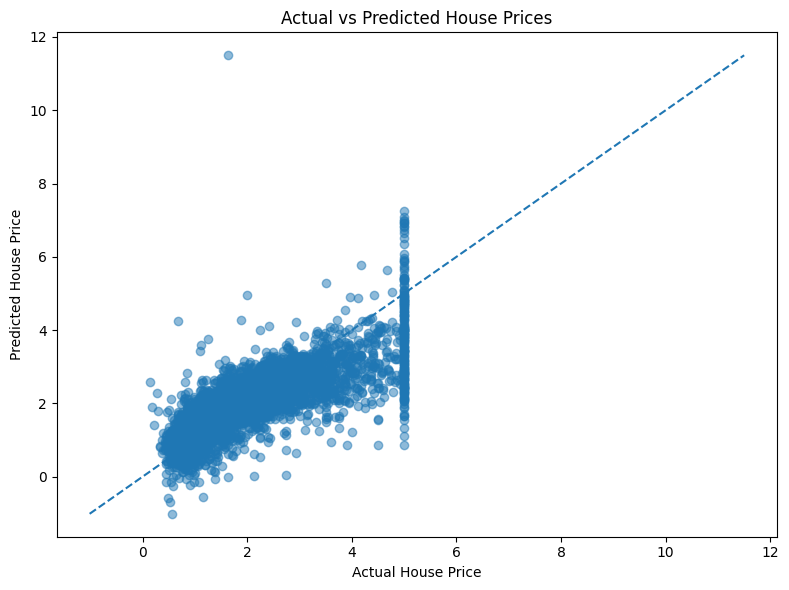

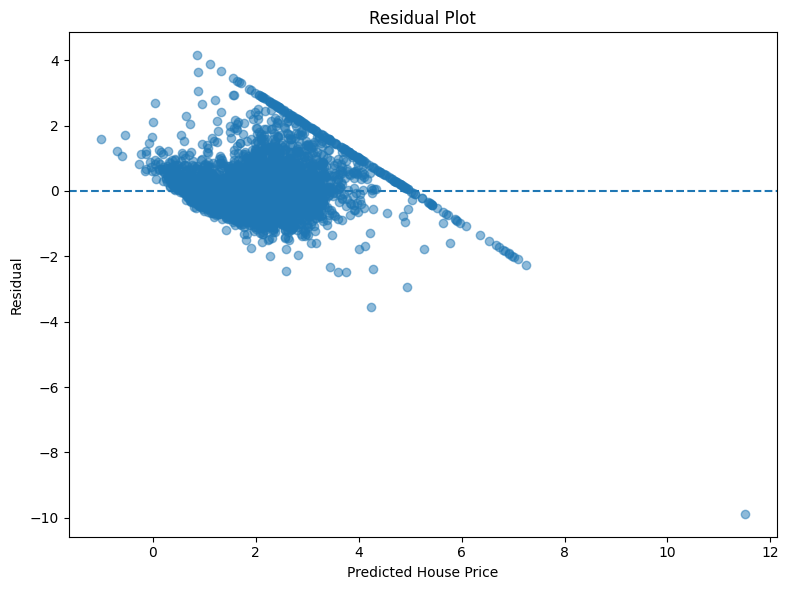


NEW HOUSE PREDICTION
Predicted house price:
2.473108730980478

Note:
The dataset target is measured in units of $100,000.

Actual estimated price:
$ 247310.87

PROJECT COMPLETED
Dataset loaded successfully.
Train/Test split completed.
Linear Regression model trained.
Predictions generated.
MSE calculated.
RMSE calculated.
R² score calculated.
Graphs generated.
New house prediction completed.

Machine Learning project completed successfully!


In [1]:
# ============================================================
# FIRST MACHINE LEARNING PROJECT
# House Price Prediction using Linear Regression
# ============================================================

# -----------------------------
# 1. Import Required Libraries
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# -----------------------------
# 2. Load the Dataset
# -----------------------------

print("=" * 60)
print("HOUSE PRICE PREDICTION USING LINEAR REGRESSION")
print("=" * 60)

print("\nLoading dataset...")

housing = fetch_california_housing(as_frame=True)

# Convert dataset into a Pandas DataFrame
df = housing.frame

print("\nDataset loaded successfully!")


# -----------------------------
# 3. Explore the Dataset
# -----------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())


# -----------------------------
# 4. Check Missing Values
# -----------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())


# -----------------------------
# 5. Separate Features and Target
# -----------------------------

# X = input features
# y = target/output

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("\nFeatures (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


# -----------------------------
# 6. Train-Test Split
# -----------------------------

# 80% data for training
# 20% data for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------
# 7. Create the Model
# -----------------------------

model = LinearRegression()


# -----------------------------
# 8. Train the Model
# -----------------------------

print("\nTraining the model...")

model.fit(X_train, y_train)

print("Model training completed!")


# -----------------------------
# 9. Make Predictions
# -----------------------------

y_pred = model.predict(X_test)


# -----------------------------
# 10. Display Predictions
# -----------------------------

print("\n" + "=" * 60)
print("PREDICTIONS")
print("=" * 60)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results.head(10))


# -----------------------------
# 11. Evaluate the Model
# -----------------------------

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)


# -----------------------------
# 12. Model Coefficients
# -----------------------------

print("\n" + "=" * 60)
print("MODEL COEFFICIENTS")
print("=" * 60)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

print("\nIntercept:", model.intercept_)


# -----------------------------
# 13. Compare Actual vs Predicted
# -----------------------------

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED")
print("=" * 60)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(20))


# -----------------------------
# 14. Visualization
# -----------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()


# -----------------------------
# 15. Residual Plot
# -----------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()


# -----------------------------
# 16. Predict a New House
# -----------------------------

print("\n" + "=" * 60)
print("NEW HOUSE PREDICTION")
print("=" * 60)

# Example house data
# Order:
# MedInc, HouseAge, AveRooms, AveBedrms,
# Population, AveOccup, Latitude, Longitude

new_house = pd.DataFrame({
    "MedInc": [5.0],
    "HouseAge": [20.0],
    "AveRooms": [5.0],
    "AveBedrms": [1.0],
    "Population": [1000.0],
    "AveOccup": [3.0],
    "Latitude": [34.0],
    "Longitude": [-118.0]
})

predicted_price = model.predict(new_house)

print("Predicted house price:")
print(predicted_price[0])

print("\nNote:")
print("The dataset target is measured in units of $100,000.")

print("\nActual estimated price:")
print("$", round(predicted_price[0] * 100000, 2))


# -----------------------------
# 17. Final Summary
# -----------------------------

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("Dataset loaded successfully.")
print("Train/Test split completed.")
print("Linear Regression model trained.")
print("Predictions generated.")
print("MSE calculated.")
print("RMSE calculated.")
print("R² score calculated.")
print("Graphs generated.")
print("New house prediction completed.")

print("\nMachine Learning project completed successfully!")